# v30_optimize — kiến trúc kd2 (head giữ-thời-gian) TRAIN THUẦN, KHÔNG teacher/KD

> Ablation đã chứng minh KD không đóng góp (α=1.0 ≥ các bản KD). Bản này = **kiến trúc kd2** (GAP+GMP+Flatten + 2 SepConv/tầng + kênh 32/48/64/96) train supervised thuần như v30 baseline (Fall×3/Trans×0.55, augment Trans ×0.9/1.1). Bỏ hẳn teacher TCN. Dùng lại `cache_v30`, bỏ qua Step 1/2.


## 📌 Tài liệu: đơn vị gyro & chuẩn hóa (v30)

- **Accel** (ADXL345): `raw×32/8192` → **g**; normalize `clip(±8g)/8` → ~[-1,1].
- **Gyro** (ITG3200): `raw×4000/65536` → **dps** (KHÔNG ×π/180); normalize **`clip(±500 dps)/500`** → ~[-1,1].

**Vì sao /500:** rà soát dataset → per-axis gyro p99.9 ≈ **349 dps**, max hoạt động ~366 dps (run), sensor bão hòa 2000. Clip **500** phủ đủ + headroom, dùng hết dải [-1,1] (so với /2000 cũ làm gyro bé tí → **chết khi quantize INT8**).

**Gyro zero-centered** (đứng yên ≈ 0) → chỉ chia, không trừ offset.

**KHỚP firmware:** firmware cũng `clip(dps,±500)/500` → train-space = deploy-space, gyro sống trên cả PC lẫn MCU.

In [6]:
# === Kích hoạt Keras 2 (legacy) cho TOÀN BỘ notebook ===
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'
!pip install -q tf-keras

import shutil

ZIP_PATH  = '/media/data3/users/hungvm/dataset/sisfall/archive.zip'
WORKSPACE = '/media/data3/users/hungvm/dataset/sisfall/workspace'

if not os.path.exists(WORKSPACE):
    os.makedirs(WORKSPACE)
    !unzip -q "{ZIP_PATH}" -d "{WORKSPACE}"
    print("Giải nén hoàn tất!")
else:
    print("Workspace đã tồn tại!")

Workspace đã tồn tại!


# 2. Tiền xử lý (Extract & Preprocess - Step 1)
Chuyển đổi gia tốc (g), góc quay (rad/s) và downsample 100Hz.


In [ ]:
import glob
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm

INPUT_DIR  = Path(WORKSPACE) / 'SisFall_dataset'
OUTPUT_DIR = Path(WORKSPACE) / 'SisFall_dataset_Processed_v30'

target_har = {'D01', 'D02', 'D03', 'D04', 'D05', 'D07', 'D08', 'D11', 'D12', 'D13', 'D15', 'D17', 'D18', 'D19'}
ACCEL_SCALE = 32.0 / 8192.0
GYRO_SCALE = 4000.0 / 65536.0   # raw -> dps (KHONG nhan pi/180), khop firmware

all_files = list(INPUT_DIR.rglob('*.txt'))
files_to_process = [f for f in all_files if f.name.startswith('F') or f.name[:3] in target_har]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for file_path in tqdm(files_to_process, desc="Preprocessing"):
    try:
        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            lines = f.readlines()
            
        data = []
        for line in lines:
            line = line.strip().rstrip(';')
            if not line: continue
            parts = line.split(',')
            if len(parts) >= 6:
                data.append([float(x) for x in parts[:6]])
                
        if not data: continue
        df = pd.DataFrame(data, columns=['ax', 'ay', 'az', 'gx', 'gy', 'gz'])
        
        df[['ax', 'ay', 'az']] *= ACCEL_SCALE
        df[['gx', 'gy', 'gz']] *= GYRO_SCALE
        df = df.iloc[::2, :].reset_index(drop=True)
        
        rel_path = file_path.relative_to(INPUT_DIR)
        out_file = OUTPUT_DIR / rel_path.parent / (file_path.stem + '.csv')
        out_file.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(out_file, index=False)
    except Exception as e:
        pass
print("Hoàn tất Step 1!")


# 3. Cắt Window (Windowing - Step 2) — bản chỉnh cho Trans/D18/D19

- **D18 (vấp khi đi)** & **D19 (nhảy nhẹ)**: chỉ lấy **1 cửa sổ Trans** tại đỉnh SVM cao nhất; phần đi bộ còn lại **bỏ hết** (không Walk, không Idle).
- **Trans augment ×3**: dịch trước/sau 20 mẫu — **chỉ cho subject TRAIN** (tránh thổi phồng Val/Test).
- D01/D02/D05→Walk, D03/D04→Run (sliding window); D07…D17→Trans(≤2 đỉnh)+Idle.

In [ ]:
import numpy as np
from pathlib import Path

WINDOW_OUTPUT_DIR = Path(WORKSPACE) / 'SisFall_dataset_Windowed_v30'
GYRO_RMS_TH = 20.0     # 20 dps (gyro trong CSV da o dps)

def rolling_rms(x, w=21):
    return np.sqrt(np.convolve(x**2, np.ones(w)/w, mode='same'))

def extract_window(df, center, window_size=200):
    start, end = center - window_size // 2, center + window_size // 2
    if start < 0: start, end = 0, window_size
    if end > len(df): end, start = len(df), max(0, len(df) - window_size)
    return df.iloc[start:end]

def classify_idle(win_df):
    ax_m, ay_m, az_m = win_df['ax'].abs().mean(), win_df['ay'].abs().mean(), win_df['az'].abs().mean()
    return 'Idle_StandSit' if (ay_m > ax_m and ay_m > az_m) else 'Idle_Lie'

def gyro_event_peaks(df, min_len=10, gap=10):
    """Moi vung gyro-RMS > nguong lien tuc = 1 su kien transition; tra ve dinh cua moi su kien."""
    gmag = np.sqrt(df['gx'].values**2 + df['gy'].values**2 + df['gz'].values**2)
    grms = rolling_rms(gmag, 21)
    idx = np.where(grms > GYRO_RMS_TH)[0]
    peaks = []
    if len(idx):
        for grp in np.split(idx, np.where(np.diff(idx) > gap)[0] + 1):
            if len(grp) >= min_len:
                peaks.append(int(grp[0] + np.argmax(grms[grp[0]:grp[-1]+1])))
    return peaks

all_processed = list(OUTPUT_DIR.rglob('*.csv'))
trans_har    = {'D07','D08','D11','D12','D13','D15','D17'}   # ngoi/dung/nam -> Trans + Idle
stumble_jump = {'D18','D19'}                                  # vap/nhay -> 1 Trans tai dinh gyro
cont_har     = {'D01','D02','D03','D04','D05'}                # di/chay lien tuc

windows_generated = 0
for f in tqdm(all_processed, desc="Windowing v30 (gyro-Trans)"):
    df = pd.read_csv(f)
    if len(df) < 200: continue
    filename, prefix = f.stem, f.stem[:3]
    out_dir = WINDOW_OUTPUT_DIR / f.parent.name
    out_dir.mkdir(parents=True, exist_ok=True)

    if filename.startswith('F'):
        # Fall: 5 cua so quanh dinh va cham (accel)
        svm = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)
        peak_idx = int(svm.values.argmax())
        for w_idx, shift in enumerate([-60,-30,0,30,60]):
            win = extract_window(df, peak_idx+shift)
            if len(win)==200:
                win.to_csv(out_dir/f"{filename}_Fall_W{w_idx:03d}.csv", index=False); windows_generated+=1

    elif prefix in stumble_jump:
        # vap/nhay: 1 cua so Trans tai dinh gyro-RMS lon nhat
        gmag = np.sqrt(df['gx'].values**2 + df['gy'].values**2 + df['gz'].values**2)
        peak = int(rolling_rms(gmag,21).argmax())
        win = extract_window(df, peak)
        if len(win)==200:
            win.to_csv(out_dir/f"{filename}_Trans_P000.csv", index=False); windows_generated+=1

    elif prefix in trans_har:
        # TRANS theo SU KIEN gyro: moi vung RMS>20dps -> 1 cua so can dinh
        peaks = gyro_event_peaks(df)
        for i, p in enumerate(peaks):
            win = extract_window(df, p)
            if len(win)==200:
                win.to_csv(out_dir/f"{filename}_Trans_E{i:03d}.csv", index=False); windows_generated+=1
        # IDLE: sliding window co tam cach MOI su kien gyro >= 80 mau
        for start in range(0, len(df)-200+1, 100):
            center = start + 100
            if all(abs(center - p) >= 80 for p in peaks):
                win = df.iloc[start:start+200]
                win.to_csv(out_dir/f"{filename}_{classify_idle(win)}_W{start//100:03d}.csv", index=False); windows_generated+=1

    elif prefix in cont_har:
        for start in range(0, len(df)-200+1, 100):
            win = df.iloc[start:start+200]
            label = "Walk" if prefix in {'D01','D02','D05'} else "Run"
            win.to_csv(out_dir/f"{filename}_{label}_W{start//100:03d}.csv", index=False); windows_generated+=1

print(f"Hoan tat Windowing v30! Tong cua so: {windows_generated}")

# 4. ML Pipeline I/O (DataPreprocessor & OutputReporter)
Đây là 2 class cốt lõi chịu trách nhiệm tổ chức Dataloader, Caching, Split Subject và Report.


In [7]:
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import shutil

class DataPreprocessor:
    def __init__(self, data_dir, cache_dir, class_names):
        self.data_dir = Path(data_dir)
        self.cache_dir = Path(cache_dir)
        self.class_names = class_names
        
        self.TRAIN_SUBJECTS = {f"SA{i:02d}" for i in range(1, 19)} | {f"SE{i:02d}" for i in range(1, 9)}
        self.VAL_SUBJECTS = {f"SA{i:02d}" for i in range(19, 22)} | {f"SE{i:02d}" for i in range(9, 12)}
        self.TEST_SUBJECTS = {f"SA{i:02d}" for i in range(22, 24)} | {f"SE{i:02d}" for i in range(12, 16)}

    def parse_filename_info(self, filename):
        if '_Trans_' in filename: return 'Trans'
        if '_StandSit_' in filename or '_Lie_' in filename: return 'Idle'
        prefix = filename[:3]
        if prefix in ['D01', 'D02', 'D05', 'D06']: return 'Walk'
        if prefix in ['D03', 'D04']: return 'Run'
        if prefix.startswith('F'): return 'Fall'
        return None

    def load_single_csv(self, file_path):
        try:
            filename = file_path.stem
            subject_id = filename.split('_')[1]
            label_str = self.parse_filename_info(filename)
            if label_str is None: return None
            label = self.class_names.index(label_str)
            df = pd.read_csv(file_path)
            if len(df) != 200: return None
            return df.to_numpy(), label, subject_id
        except: return None

    def load_or_create_dataset(self):
        self.cache_dir.mkdir(exist_ok=True, parents=True)
        train_x, train_y = self.cache_dir/'X_train.npy', self.cache_dir/'y_train.npy'
        val_x, val_y = self.cache_dir/'X_val.npy', self.cache_dir/'y_val.npy'
        test_x, test_y = self.cache_dir/'X_test.npy', self.cache_dir/'y_test.npy'
        
        if all(p.exists() for p in [train_x, train_y, val_x, val_y, test_x, test_y]):
            print("[*] Load data từ Cache...")
            return (np.load(train_x), np.load(train_y), np.load(val_x), np.load(val_y), np.load(test_x), np.load(test_y))

        print(f"[*] Đang đọc file CSV từ {self.data_dir}...")
        all_files = list(self.data_dir.rglob('*.csv'))
        
        if len(all_files) == 0:
            raise FileNotFoundError(f"LỖI: Không tìm thấy file CSV nào trong {self.data_dir}. Vui lòng chạy lại Bước 2 (Windowing)!")
            
        X_train, y_train, X_val, y_val, X_test, y_test = [], [], [], [], [], []
        
        with ThreadPoolExecutor(max_workers=8) as executor:
            for res in tqdm(executor.map(self.load_single_csv, all_files), total=len(all_files)):
                if res is None: continue
                data, label, sub = res
                if sub in self.TRAIN_SUBJECTS: X_train.append(data); y_train.append(label)
                elif sub in self.VAL_SUBJECTS: X_val.append(data); y_val.append(label)
                elif sub in self.TEST_SUBJECTS: X_test.append(data); y_test.append(label)
                    
        X_train, y_train = np.array(X_train, dtype=np.float32), np.array(y_train, dtype=np.int32)
        X_val, y_val = np.array(X_val, dtype=np.float32), np.array(y_val, dtype=np.int32)
        X_test, y_test = np.array(X_test, dtype=np.float32), np.array(y_test, dtype=np.int32)
        
        np.save(train_x, X_train); np.save(train_y, y_train)
        np.save(val_x, X_val); np.save(val_y, y_val)
        np.save(test_x, X_test); np.save(test_y, y_test)
        
        return X_train, y_train, X_val, y_val, X_test, y_test

    def apply_preprocessing(self, X_train, X_val, X_test):
        # Sửa lỗi Index Error: Chỉ cắt mảng nếu mảng thực sự có chứa dữ liệu (3 chiều)
        for X in [X_train, X_val, X_test]:
            if X.ndim == 3 and X.shape[0] > 0:
                X[:, :, 0:3] = np.clip(X[:, :, 0:3], -8.0, 8.0) / 8.0
                # v30: gyro o dps -> normalize = clip +-500 roi /500 (KHOP firmware: firmware cung clip+-500/500).
                # Range thuc p99.9 ~349 dps -> clip 500 phu du; gyro zero-centered nen chi chia, khong tru offset.
                X[:, :, 3:6] = np.clip(X[:, :, 3:6], -500.0, 500.0) / 500.0
        return X_train, X_val, X_test

    def get_balanced_class_weights(self, y_train, class_weight_modifiers=None):
        if len(y_train) == 0: return {}
        vals = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
        weights = dict(zip(np.unique(y_train), vals))
        if class_weight_modifiers:
            for cls_name, mod in class_weight_modifiers.items():
                if cls_name in self.class_names:
                    weights[self.class_names.index(cls_name)] *= mod
        return weights

class OutputReporter:
    def __init__(self, out_dir, class_names):
        self.out_dir = Path(out_dir)
        self.out_dir.mkdir(exist_ok=True, parents=True)
        self.class_names = class_names

    def plot_training_history(self, history, version="v_colab"):
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1); plt.plot(history.history['accuracy'], label='Train'); plt.plot(history.history['val_accuracy'], label='Val'); plt.legend(); plt.title('Accuracy')
        plt.subplot(1, 2, 2); plt.plot(history.history['loss'], label='Train'); plt.plot(history.history['val_loss'], label='Val'); plt.legend(); plt.title('Loss')
        plt.tight_layout(); plt.savefig(self.out_dir / f'history_{version}.png'); plt.show()

    def evaluate_and_report(self, model, X_test, y_test, version="v_colab", fall_threshold=0.25):
        if len(X_test) == 0: return
        fall_idx = self.class_names.index('Fall')
        y_pred_probs = model.predict(X_test, batch_size=256)
        y_pred = np.argmax(y_pred_probs, axis=1)
        y_pred[y_pred_probs[:, fall_idx] >= fall_threshold] = fall_idx
        
        report_str = "\n" + "="*50 + "\n"
        report_str += f"BÁO CÁO PHÂN LOẠI TẬP KIỂM THỬ - {version} (Threshold {fall_threshold})\n"
        report_str += "="*50 + "\n"
        
        cls_report = classification_report(y_test, y_pred, target_names=self.class_names, digits=4)
        report_str += cls_report + "\n"
        print(report_str)
        
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8,6))
        plt.imshow(cm, cmap=plt.cm.Blues); plt.colorbar()
        plt.xticks(np.arange(len(self.class_names)), self.class_names, rotation=45)
        plt.yticks(np.arange(len(self.class_names)), self.class_names)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, format(cm[i,j],'d'), ha="center", color="white" if cm[i,j] > cm.max()/2. else "black")
        plt.ylabel('Nhãn Thực Tế')
        plt.xlabel('Nhãn Dự Đoán')
        plt.tight_layout()
        plt.savefig(self.out_dir / f'confusion_matrix_{version}.png')
        plt.show()
        
        true_falls = np.sum(y_test == fall_idx)
        detected_falls = cm[fall_idx, fall_idx]
        recall_fall = (detected_falls / true_falls) * 100 if true_falls > 0 else 0
        
        eval_str = "\n" + "="*50 + "\n"
        eval_str += "KẾT QUẢ ĐÁNH GIÁ CHUYÊN BIỆT LỚP TÉ NGÃ (FALL):\n"
        eval_str += f"  - Số ca ngã thực tế: {true_falls}\n"
        eval_str += f"  - Số ca ngã phát hiện đúng: {detected_falls}\n"
        eval_str += f"  - TỶ LỆ RECALL TÉ NGÃ: {recall_fall:.2f}%\n"
        eval_str += "="*50 + "\n"
        
        print(eval_str)
        report_str += eval_str
        
        with open(self.out_dir / f'report_{version}.txt', 'w', encoding='utf-8') as rf:
            rf.write(report_str)
        print(f"[*] Đã lưu báo cáo tại {self.out_dir / f'report_{version}.txt'}")


# 5. Kiến trúc Model — v29 (CNN thuần ESP-NN, head avg+max)

In [8]:
import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv1D, SeparableConv1D, BatchNormalization, Activation,
                                     MaxPooling1D, GlobalAveragePooling1D, Flatten, Concatenate, Dropout, Dense)
from tensorflow.keras.models import Model

def build_model(input_shape=(200, 6), n_classes=5):
    # v30_optimize = kien truc kd2 (giu cau truc thoi gian) train THUAN (khong KD, khong teacher TCN).
    #   Head GAP+GMP+Flatten(map tho 12x96) giu truc thoi gian (pha tran Idle/Trans);
    #   2 SeparableConv k3 stride-1 moi tang dau + kenh 32/48/64/96. Thuan op ESP-NN.
    inp = Input(shape=input_shape)
    x = Conv1D(32, 3, strides=2, padding='same', use_bias=False)(inp)        # 200->100
    x = BatchNormalization()(x); x = Activation('relu6')(x)
    x = SeparableConv1D(48, 3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x); x = Activation('relu6')(x)
    x = SeparableConv1D(48, 3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x); x = Activation('relu6')(x)
    x = MaxPooling1D(2)(x)                                                    # 100->50
    x = SeparableConv1D(64, 3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x); x = Activation('relu6')(x)
    x = SeparableConv1D(64, 3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x); x = Activation('relu6')(x)
    x = MaxPooling1D(2)(x)                                                    # 50->25
    x = SeparableConv1D(96, 3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x); x = Activation('relu6')(x)
    x = MaxPooling1D(2)(x)                                                    # 25->12
    a = GlobalAveragePooling1D()(x)                              # (96,)
    m = MaxPooling1D(pool_size=int(x.shape[1]))(x); m = Flatten()(m)   # (96,) GMP-as-MaxPool
    f = Flatten()(x)                                            # (12*96=1152,) layout thoi gian
    x = Concatenate()([a, m, f])
    x = Dropout(0.3)(x)
    outputs = Dense(n_classes, activation='softmax')(x)
    model = Model(inp, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
                  metrics=['accuracy'])
    return model

# 6. Huấn luyện + Đánh giá

[*] Load data từ Cache...
Da augment Trans x0.9/x1.1 -> 2683 x3
Phân bố nhãn train: {'Walk': 8427, 'Run': 5217, 'Idle': 7537, 'Trans': 8049, 'Fall': 7125}
Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 200, 6)]             0         []                            
                                                                                                  
 conv1d_1 (Conv1D)           (None, 100, 32)              576       ['input_3[0][0]']             
                                                                                                  
 batch_normalization_6 (Bat  (None, 100, 32)              128       ['conv1d_1[0][0]']            
 chNormalization)                                                                                 
                                    

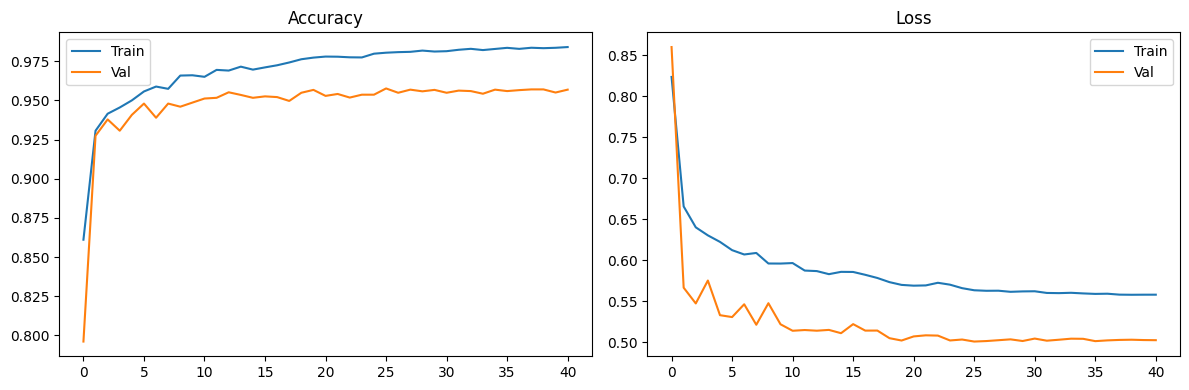

24/24 [==============================] - 0s 2ms/step

BÁO CÁO PHÂN LOẠI TẬP KIỂM THỬ - v30_optimize (Threshold 0.25)
              precision    recall  f1-score   support

        Walk     0.9712    0.9365    0.9535      1906
         Run     0.9814    0.9724    0.9769      1085
        Idle     0.9273    0.9572    0.9420      1798
       Trans     0.8857    0.9295    0.9071       567
        Fall     0.9879    0.9773    0.9826       750

    accuracy                         0.9533      6106
   macro avg     0.9507    0.9546    0.9524      6106
weighted avg     0.9542    0.9533    0.9535      6106




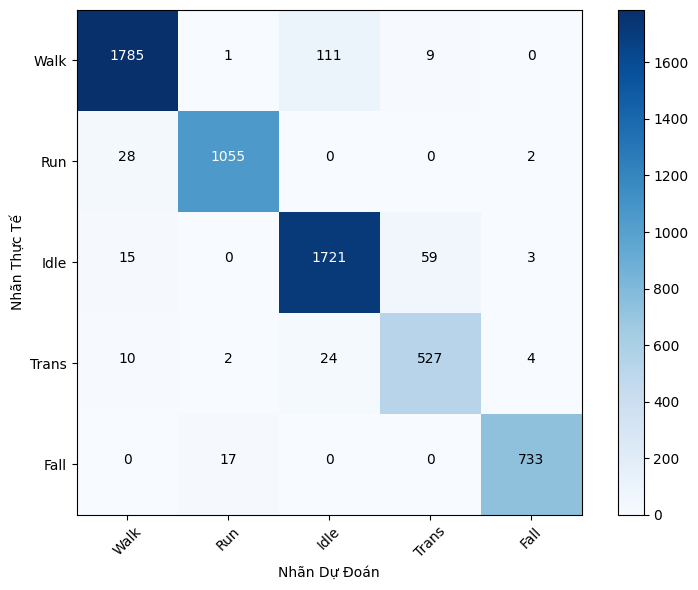


KẾT QUẢ ĐÁNH GIÁ CHUYÊN BIỆT LỚP TÉ NGÃ (FALL):
  - Số ca ngã thực tế: 750
  - Số ca ngã phát hiện đúng: 733
  - TỶ LỆ RECALL TÉ NGÃ: 97.73%

[*] Đã lưu báo cáo tại /media/data3/users/hungvm/dataset/sisfall/workspace/output_v30_optimize/report_v30_optimize.txt


In [9]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

class FallDetectionTrainerResize(DataPreprocessor, OutputReporter):
    def __init__(self):
        data_dir  = f'{WORKSPACE}/SisFall_dataset_Windowed_v30'
        cache_dir = f'{WORKSPACE}/cache_v30'
        out_dir   = f'{WORKSPACE}/output_v30_optimize'
        class_names = ['Walk', 'Run', 'Idle', 'Trans', 'Fall']
        DataPreprocessor.__init__(self, data_dir, cache_dir, class_names)
        OutputReporter.__init__(self, out_dir, class_names)
        self.version = "v30_optimize"

trainer = FallDetectionTrainerResize()
checkpoint_path = Path(trainer.out_dir) / f'best_model_{trainer.version}.keras'

# 1. Nạp + tiền xử lý
X_train, y_train, X_val, y_val, X_test, y_test = trainer.load_or_create_dataset()

# === Augment Trans: nhan bien do x0.9 va x1.1 (CHI train, TRUOC preprocessing) ===
ti = trainer.class_names.index('Trans')
tmask = np.where(y_train == ti)[0]
if len(tmask) > 0:
    Xt = X_train[tmask]
    X_train = np.concatenate([X_train, (Xt*0.9).astype(np.float32), (Xt*1.1).astype(np.float32)], axis=0)
    y_train = np.concatenate([y_train, np.full(len(Xt), ti, y_train.dtype), np.full(len(Xt), ti, y_train.dtype)])
    _p = np.random.RandomState(42).permutation(len(X_train)); X_train, y_train = X_train[_p], y_train[_p]
    print('Da augment Trans x0.9/x1.1 ->', len(tmask), 'x3')

X_train, X_val, X_test = trainer.apply_preprocessing(X_train, X_val, X_test)
print("Phân bố nhãn train:", {trainer.class_names[k]: int((y_train==k).sum()) for k in range(5)})

# 2. Class weights (đẩy Fall x3)
weight_modifiers = {'Fall': 3.0, 'Trans': 0.55, 'Idle': 1.0}
class_weights = trainer.get_balanced_class_weights(y_train, weight_modifiers)

# 3. One-hot
y_train_oh = to_categorical(y_train, num_classes=5)
y_val_oh = to_categorical(y_val, num_classes=5)

# 4. Build model RESIZE
model = build_model(input_shape=(200, 6), n_classes=5)
model.summary()

# 5. Callbacks
callbacks = [
    EarlyStopping(monitor='val_accuracy', mode='max', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_accuracy', mode='max', factor=0.5, patience=5, min_lr=1e-6),
    ModelCheckpoint(filepath=str(checkpoint_path), monitor='val_accuracy', mode='max', save_best_only=True, verbose=1),
]

# 6. Train
history = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=100, batch_size=64,
    class_weight=class_weights,
    callbacks=callbacks, verbose=1
)

# 7. Đánh giá
trainer.plot_training_history(history, version=trainer.version)
trainer.evaluate_and_report(model, X_test, y_test, version=trainer.version, fall_threshold=0.25)

# 7. Export INT8 TFLite → `model_data_v1_resize.cc/.h`

In [10]:
# === Export INT8 TFLite + sinh model_data .cc/.h (NHUNG SAN ops cho TFLM wrapper) ===
import numpy as np
ver = trainer.version
out_dir = Path(trainer.out_dir)

np.random.seed(42)
rep_idx = np.random.choice(len(X_train), size=min(300, len(X_train)), replace=False)
def representative_data_gen():
    for i in rep_idx:
        yield [X_train[i:i+1].astype(np.float32)]

static_in = tf.keras.Input(batch_shape=(1, 200, 6), dtype='float32')
static_model = tf.keras.models.clone_model(model, input_tensors=static_in)
static_model.set_weights(model.get_weights())

converter = tf.lite.TFLiteConverter.from_keras_model(static_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
tflite_model = converter.convert()

tflite_path = out_dir / f'model_{ver}_int8.tflite'
tflite_path.write_bytes(tflite_model)
print(f"[*] Saved {tflite_path}  ({len(tflite_model)} bytes)")

it = tf.lite.Interpreter(model_content=tflite_model); it.allocate_tensors()
inp = it.get_input_details()[0]; outp = it.get_output_details()[0]
all_ops = sorted({d['op_name'] for d in it._get_ops_details()})
NON_REG = {'DELEGATE', 'CALL_ONCE', 'CUSTOM'}
reg_ops = [o for o in all_ops if o not in NON_REG]
in_scale, in_zp = inp['quantization']; out_scale, out_zp = outp['quantization']
in_len = int(np.prod(inp['shape'])); out_len = int(np.prod(outp['shape']))
print("[*] Input :", inp['shape'], inp['dtype'])
print("[*] Output:", outp['shape'], outp['dtype'])
print("[*] Ops can dang ky:", reg_ops)

OP2ADD = {
    'CONV_2D':'AddConv2D','DEPTHWISE_CONV_2D':'AddDepthwiseConv2D','MAX_POOL_2D':'AddMaxPool2D',
    'AVERAGE_POOL_2D':'AddAveragePool2D','MEAN':'AddMean','FULLY_CONNECTED':'AddFullyConnected',
    'SOFTMAX':'AddSoftmax','LOGISTIC':'AddLogistic','RELU6':'AddRelu6','RESHAPE':'AddReshape',
    'ADD':'AddAdd','MUL':'AddMul','CONCATENATION':'AddConcatenation','PAD':'AddPad',
    'QUANTIZE':'AddQuantize','DEQUANTIZE':'AddDequantize','STRIDED_SLICE':'AddStridedSlice',
}
res_lines = []
for o in reg_ops:
    m2 = OP2ADD.get(o)
    res_lines.append(f"//   resolver.{m2}();" if m2 else f"//   /* op '{o}': tu tra cuu Add method */")

meta = (
    "// ============================================================\n"
    f"// AUTO-GENERATED model data  --  {ver}\n"
    f"// TFLite INT8 size : {len(tflite_model)} bytes\n"
    "// ------------------------------------------------------------\n"
    f"// Input  : shape={list(inp['shape'])} dtype={inp['dtype'].__name__} quant(scale={in_scale:.8g}, zero_point={in_zp})\n"
    f"// Output : shape={list(outp['shape'])} dtype={outp['dtype'].__name__} quant(scale={out_scale:.8g}, zero_point={out_zp})\n"
    "// INT8<->real:  q = round(real/scale)+zero_point ; real = (q-zero_point)*scale\n"
    "// ------------------------------------------------------------\n"
    f"// OPS cua mang ({len(reg_ops)}) -- dang ky DUNG nhung op nay:\n"
    + "".join(f"//   - {o}\n" for o in reg_ops)
    + (f"// (Bo qua pseudo-op: {', '.join(o for o in all_ops if o in NON_REG)})\n" if any(o in NON_REG for o in all_ops) else "")
    + "//\n"
    f"// GOI Y MicroMutableOpResolver (so op = {len(reg_ops)}):\n"
    f"//   static tflite::MicroMutableOpResolver<{len(reg_ops)}> resolver;\n"
    + "".join(l + "\n" for l in res_lines)
    + "// ============================================================\n"
)

body, line = '', '  '
for i, b in enumerate(tflite_model):
    line += f'0x{b:02x}, '
    if (i+1) % 12 == 0:
        body += line.rstrip() + '\n'; line = '  '
if line.strip():
    body += line.rstrip()
body = body.rstrip(', \n')

cc = (meta + '#include "model_data.h"\n\n'
      f'const unsigned char g_model_data[] alignas(16) = {{\n{body}\n}};\n\n'
      f'const unsigned int g_model_data_len = {len(tflite_model)};\n')
(out_dir / f'model_data_{ver}.cc').write_text(cc, encoding='utf-8')

h = (meta + "#ifndef MODEL_DATA_H_\n#define MODEL_DATA_H_\n\n"
     f"#define MODEL_INPUT_LEN   {in_len}\n#define MODEL_OUTPUT_LEN  {out_len}\n#define MODEL_NUM_OPS     {len(reg_ops)}\n\n"
     '#ifdef __cplusplus\nextern "C" {\n#endif\n\n'
     "extern const unsigned char g_model_data[];\nextern const unsigned int g_model_data_len;\n\n"
     "#ifdef __cplusplus\n}\n#endif\n\n#endif  // MODEL_DATA_H_\n")
(out_dir / f'model_data_{ver}.h').write_text(h, encoding='utf-8')
print(f"[*] Da sinh model_data_{ver}.cc / .h")


INFO:tensorflow:Assets written to: /tmp/tmpp3a3s3wt/assets


INFO:tensorflow:Assets written to: /tmp/tmpp3a3s3wt/assets


[*] Saved /media/data3/users/hungvm/dataset/sisfall/workspace/output_v30_optimize/model_v30_optimize_int8.tflite  (56144 bytes)
[*] Input : [  1 200   6] <class 'numpy.int8'>
[*] Output: [1 5] <class 'numpy.int8'>
[*] Ops can dang ky: ['CONCATENATION', 'CONV_2D', 'DEPTHWISE_CONV_2D', 'FULLY_CONNECTED', 'MAX_POOL_2D', 'MEAN', 'RESHAPE', 'SOFTMAX']
[*] Da sinh model_data_v30_optimize.cc / .h


/media/data3/users/hungvm/anaconda3/envs/har_fall/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1782118082.656921  808508 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1782118082.656932  808508 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1782118082.657061  808508 reader.cc:83] Reading SavedModel from: /tmp/tmpp3a3s3wt
I0000 00:00:1782118082.660003  808508 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1782118082.660008  808508 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpp3a3s3wt
I0000 00:00:1782118082.674351  808508 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1782118082.713081  808508 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpp3a3s3wt
I0000 00:00:1782118082.731260  808508 loader.cc:471] Sa